# Proyecto: Realistic Loan Approval Dataset | US & Canada

**Base de datos:** `Realistic Loan Approval Dataset | US & Canada` — Kaggle

**Enlace:** https://www.kaggle.com/datasets/parthpatel2130/realistic-loan-approval-dataset-us-and-canada

**Autor:** Valeria Duque Moreno y Deyson Ortiz Restrepo

## Contenido
1. Descarga y descripción del dataset
2. Análisis Exploratorio de Datos (EDA)
3. Preprocesamiento de datos
4. Validación cruzada (10 folds) y entrenamiento de modelos
    - 4.1 Árboles de Decisión
    - 4.2 Comité de máquinas (Bagging) con Regresión y Árboles
    - 4.3 Random Forest
    - 4.4 AdaBoost
    - 4.5 XGBoost
5. Comparación de modelos
6. Guardado del mejor modelo con `joblib`
7. Conclusiones

## 1. Descarga y descripción del dataset

### 1.1 Descarga automática desde Kaggle

In [ ]:
# Instalación de librerías necesarias
!pip install kagglehub xgboost -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Descarga la última versión del dataset directamente desde Kaggle
dataset_path = kagglehub.dataset_download(
    "parthpatel2130/realistic-loan-approval-dataset-us-and-canada"
)

print("Dataset descargado en:", dataset_path)

Using Colab cache for faster access to the 'realistic-loan-approval-dataset-us-and-canada' dataset.
Dataset descargado en: /kaggle/input/realistic-loan-approval-dataset-us-and-canada


In [ ]:
#Listamos los archivos descargados para ubicar el CSV
archivos = os.listdir(dataset_path)
print("Archivos disponibles:", archivos)

csv_files = [f for f in archivos if f.lower().endswith(".csv")]
assert len(csv_files) > 0, "No se encontró ningún archivo .csv en el dataset descargado."
csv_path = os.path.join(dataset_path, csv_files[0])
print("Archivo CSV a cargar:", csv_path)

Archivos disponibles: ['Loan_approval_data_2025.csv']
Archivo CSV a cargar: /kaggle/input/realistic-loan-approval-dataset-us-and-canada/Loan_approval_data_2025.csv


In [ ]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv(csv_path)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (50000, 20)


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


### 1.2 Descripción detallada del dataset

### Fuente y dominio del problema

El conjunto de datos utilizado corresponde a **Realistic Loan Approval Dataset | US & Canada**, publicado por Parth Patel en la plataforma Kaggle. La fuente original del conjunto de datos se encuentra disponible en Kaggle y está orientada al análisis de solicitudes de préstamos en los contextos de Estados Unidos y Canadá. El dataset reúne diferentes características relacionadas con los solicitantes y sus condiciones financieras, que pueden ser utilizadas para analizar los factores asociados con la aprobación o el rechazo de una solicitud de crédito.

El conjunto de datos pertenece al **dominio financiero**, específicamente al área de **servicios financieros, crédito y evaluación del riesgo crediticio**. El problema se relaciona con el proceso mediante el cual una entidad financiera analiza las características de una persona antes de decidir si aprueba o rechaza una solicitud de préstamo. Desde la perspectiva de Ciencia de Datos, este problema puede abordarse mediante técnicas de **aprendizaje supervisado**, debido a que se cuenta con un resultado conocido para las solicitudes utilizadas en el entrenamiento del modelo. En particular, corresponde a un problema de **clasificación binaria**, donde el objetivo consiste en predecir si una solicitud será aprobada (Approved) o rechazada (Rejected) a partir de variables relacionadas con el perfil financiero y demográfico del solicitante, como sus ingresos, edad, información crediticia y nivel de endeudamiento.

Este tipo de análisis tiene aplicaciones en **credit scoring, evaluación del riesgo crediticio, automatización de procesos de aprobación y apoyo a la toma de decisiones financieras**. El uso de modelos predictivos en este contexto permite identificar patrones presentes en los datos históricos y utilizarlos para generar predicciones sobre nuevas solicitudes. Sin embargo, al tratarse de un conjunto de datos publicado en Kaggle, los resultados obtenidos deben interpretarse dentro del contexto y las características específicas del dataset y no necesariamente como una representación directa del funcionamiento de una institución financiera real.

### Utilidad / objetivo de negocio

Una entidad financiera (banco, fintech, cooperativa de crédito) necesita decidir, de forma rápida y consistente, si aprueba o no una solicitud de crédito con base en el perfil demográfico, financiero y de comportamiento crediticio del solicitante. Un modelo predictivo permite:
- Automatizar y acelerar el proceso de aprobación.
- Reducir el riesgo de otorgar créditos a solicitantes con alta probabilidad de incumplimiento.
- Aplicar criterios de decisión consistentes y auditables.
- Priorizar la revisión manual únicamente de los casos "límite" (probabilidad cercana a 0.5).

### Variable de salida

`loan_status`: variable **binaria** (1 = préstamo **aprobado**, 0 = préstamo **rechazado/negado**).

### Variables (features) del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `customer_id` | Identificador (string) | Identificador único del cliente. No aporta información predictiva → se elimina. |
| `age` | Numérica continua | Edad del solicitante (años). |
| `occupation_status` | Categórica nominal | Situación laboral: `Employed`, `Self-Employed`, `Student`. |
| `years_employed` | Numérica continua | Años en el empleo actual. |
| `annual_income` | Numérica continua | Ingreso anual bruto del solicitante (USD/CAD). |
| `credit_score` | Numérica discreta | Puntaje de crédito (score crediticio, tipo FICO). |
| `credit_history_years` | Numérica continua | Años de historial crediticio. |
| `savings_assets` | Numérica continua | Valor de ahorros / activos líquidos. |
| `current_debt` | Numérica continua | Deuda actual total del solicitante. |
| `defaults_on_file` | Numérica binaria (0/1) | Indica si el solicitante tiene incumplimientos registrados. |
| `delinquencies_last_2yrs` | Numérica discreta (conteo) | Número de pagos atrasados en los últimos 2 años. |
| `derogatory_marks` | Numérica discreta (conteo) | Número de marcas negativas en el reporte crediticio. |
| `product_type` | Categórica nominal | Tipo de producto solicitado: `Credit Card`, `Personal Loan`, `Line of Credit`. |
| `loan_intent` | Categórica nominal | Propósito del préstamo: `Business`, `Home Improvement`, `Debt Consolidation`, `Education`, `Medical`, `Personal`. |
| `loan_amount` | Numérica continua | Monto solicitado. |
| `interest_rate` | Numérica continua | Tasa de interés ofrecida (%). |
| `debt_to_income_ratio` | Numérica continua (ratio) | Deuda total / ingreso. |
| `loan_to_income_ratio` | Numérica continua (ratio) | Monto del préstamo / ingreso. |
| `payment_to_income_ratio` | Numérica continua (ratio) | Cuota estimada / ingreso. |
| **`loan_status`** | **Categórica binaria (target)** | **1 = Aprobado, 0 = Rechazado.** |

En total: **20 columnas** (18 predictoras + 1 identificador + 1 variable objetivo) y **50,000 registros**.

## 2. Análisis Exploratorio de Datos (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [ ]:
print("Análisis de los resultados obtenidos (df.info()):\n")
n_num = df.select_dtypes(include=[np.number]).shape[1]
n_obj = df.select_dtypes(include=["object"]).shape[1]
mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"El dataset tiene {df.shape[0]:,} registros y {df.shape[1]} columnas: {n_num} numéricas y "
      f"{n_obj} de tipo texto (categóricas).")

Análisis de los resultados obtenidos (df.info()):

El dataset tiene 50,000 registros y 20 columnas: 16 numéricas y 4 de tipo texto (categóricas).


In [ ]:
# Duplicados y valores nulos
n_dup = df.duplicated().sum()
n_nulls = df.isnull().sum()

print("Registros duplicados:", n_dup)
print("\nValores nulos por columna:")
print(n_nulls)

Registros duplicados: 0

Valores nulos por columna:
customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64


In [ ]:
# Eliminamos el identificador: no aporta valor predictivo
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

df.shape

(50000, 19)

### 2.1 Variables numéricas

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "loan_status"]
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numéricas:", numeric_cols)
print("\nVariables categóricas:", categorical_cols)

df[numeric_cols].describe().T

Variables numéricas: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio']

Variables categóricas: ['occupation_status', 'product_type', 'loan_intent']


,count,mean,std,min,25%,50%,75%,max
age,50000.0,34.957060,11.118603,18.000,26.000,35.000,43.00000,70.000
years_employed,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
annual_income,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
credit_score,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
credit_history_years,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
savings_assets,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
current_debt,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
defaults_on_file,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
delinquencies_last_2yrs,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
derogatory_marks,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


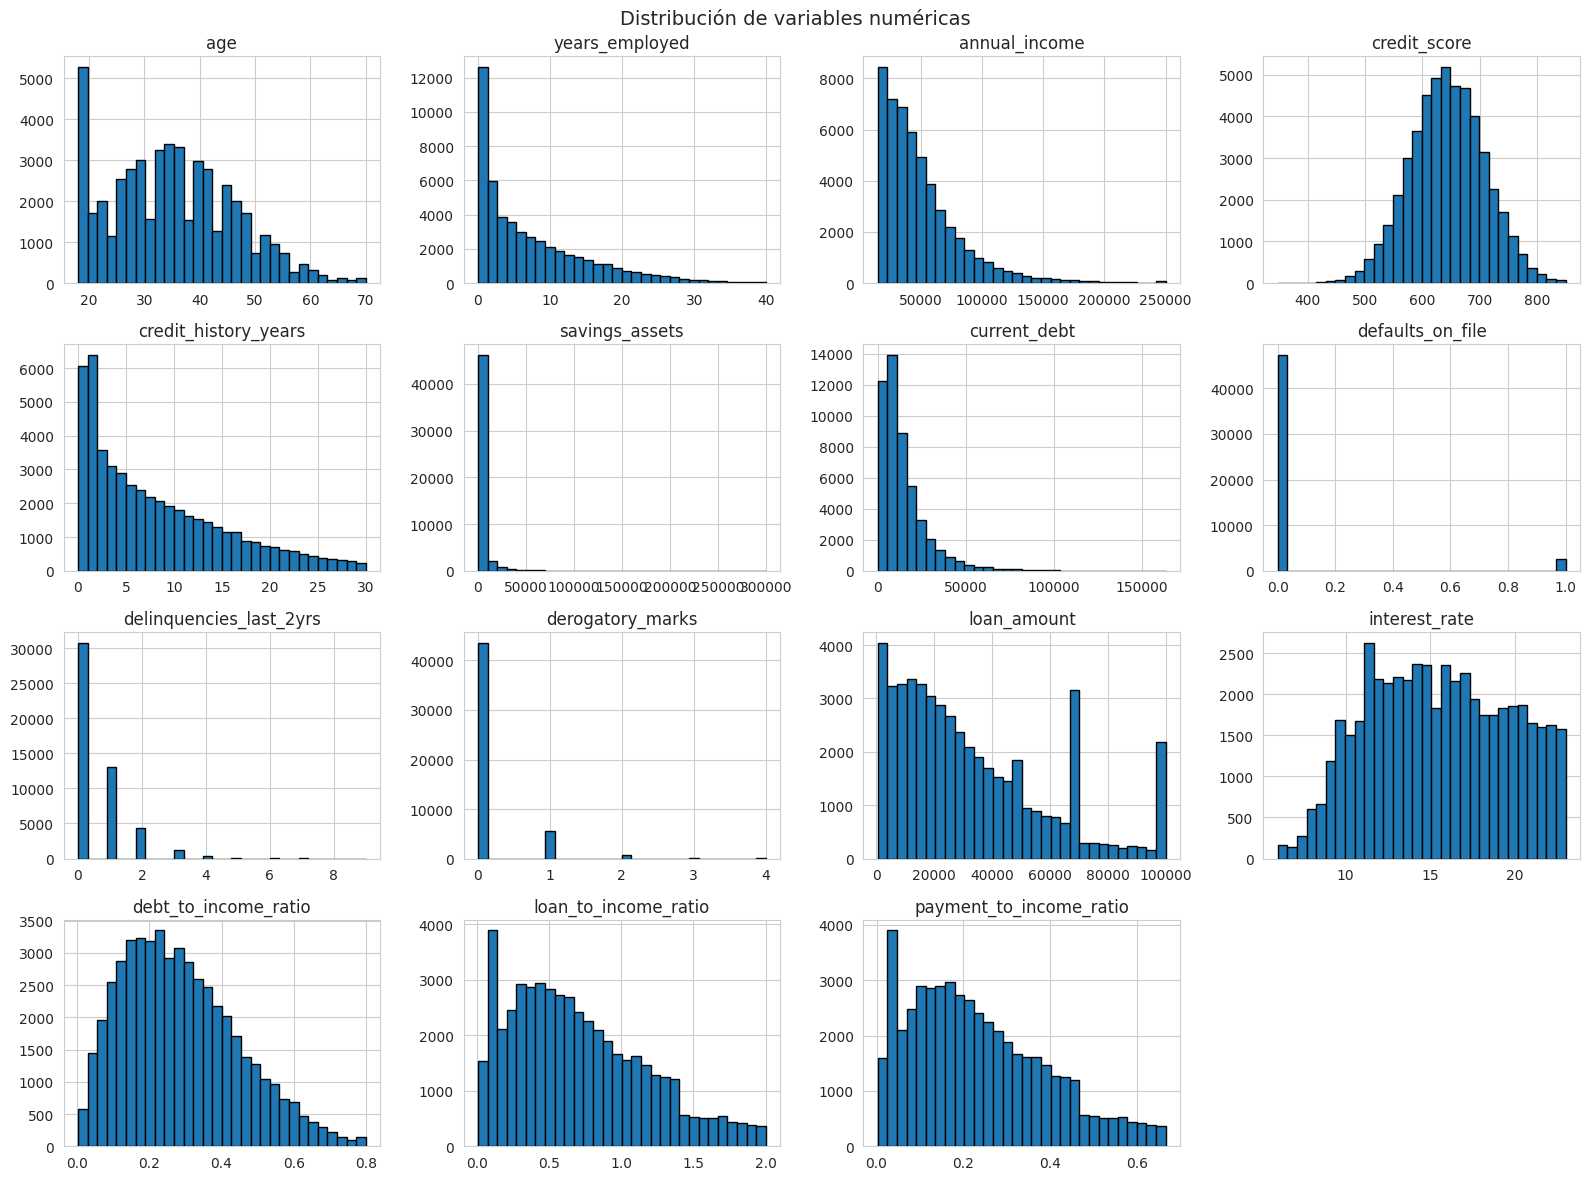

In [ ]:
# Distribución de cada variable numérica
df[numeric_cols].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()



* **Diferencias de Escala:** Existe una disparidad significativa en las métricas. Variables monetarias como `annual_income` (media de 50,062, máximo de 250,000) y `loan_amount` (media de 33,041) operan en decenas y centenas de miles. En contraste, los indicadores de endeudamiento como `debt_to_income_ratio` y `loan_to_income_ratio` son valores decimales pequeños (medias de 0.28 y 0.70 respectivamente). Esta diferencia evidencia la necesidad de escalar o normalizar los datos antes de aplicar los modelos predictivos.


* **Distribución y Valores Atípicos:** La edad (`age`) presenta un rango lógico entre 18 y 70 años, concentrando el 50% de los solicitantes entre los 26 y 43 años. Sin embargo, variables como `savings_assets` muestran una fuerte asimetría positiva; el 75% de los solicitantes tiene ahorros inferiores a $2,271, pero el valor máximo se dispara hasta los 300,000.


* **Comportamiento Crediticio:** Los historiales de incumplimiento, como `defaults_on_file`, `delinquencies_last_2yrs` y `derogatory_marks`, tienen medianas y primeros cuartiles anclados fuertemente en cero. Esto indica que la gran mayoría de la muestra tiene un buen historial, lo que resulta fundamental para perfilar el riesgo crediticio de forma efectiva.




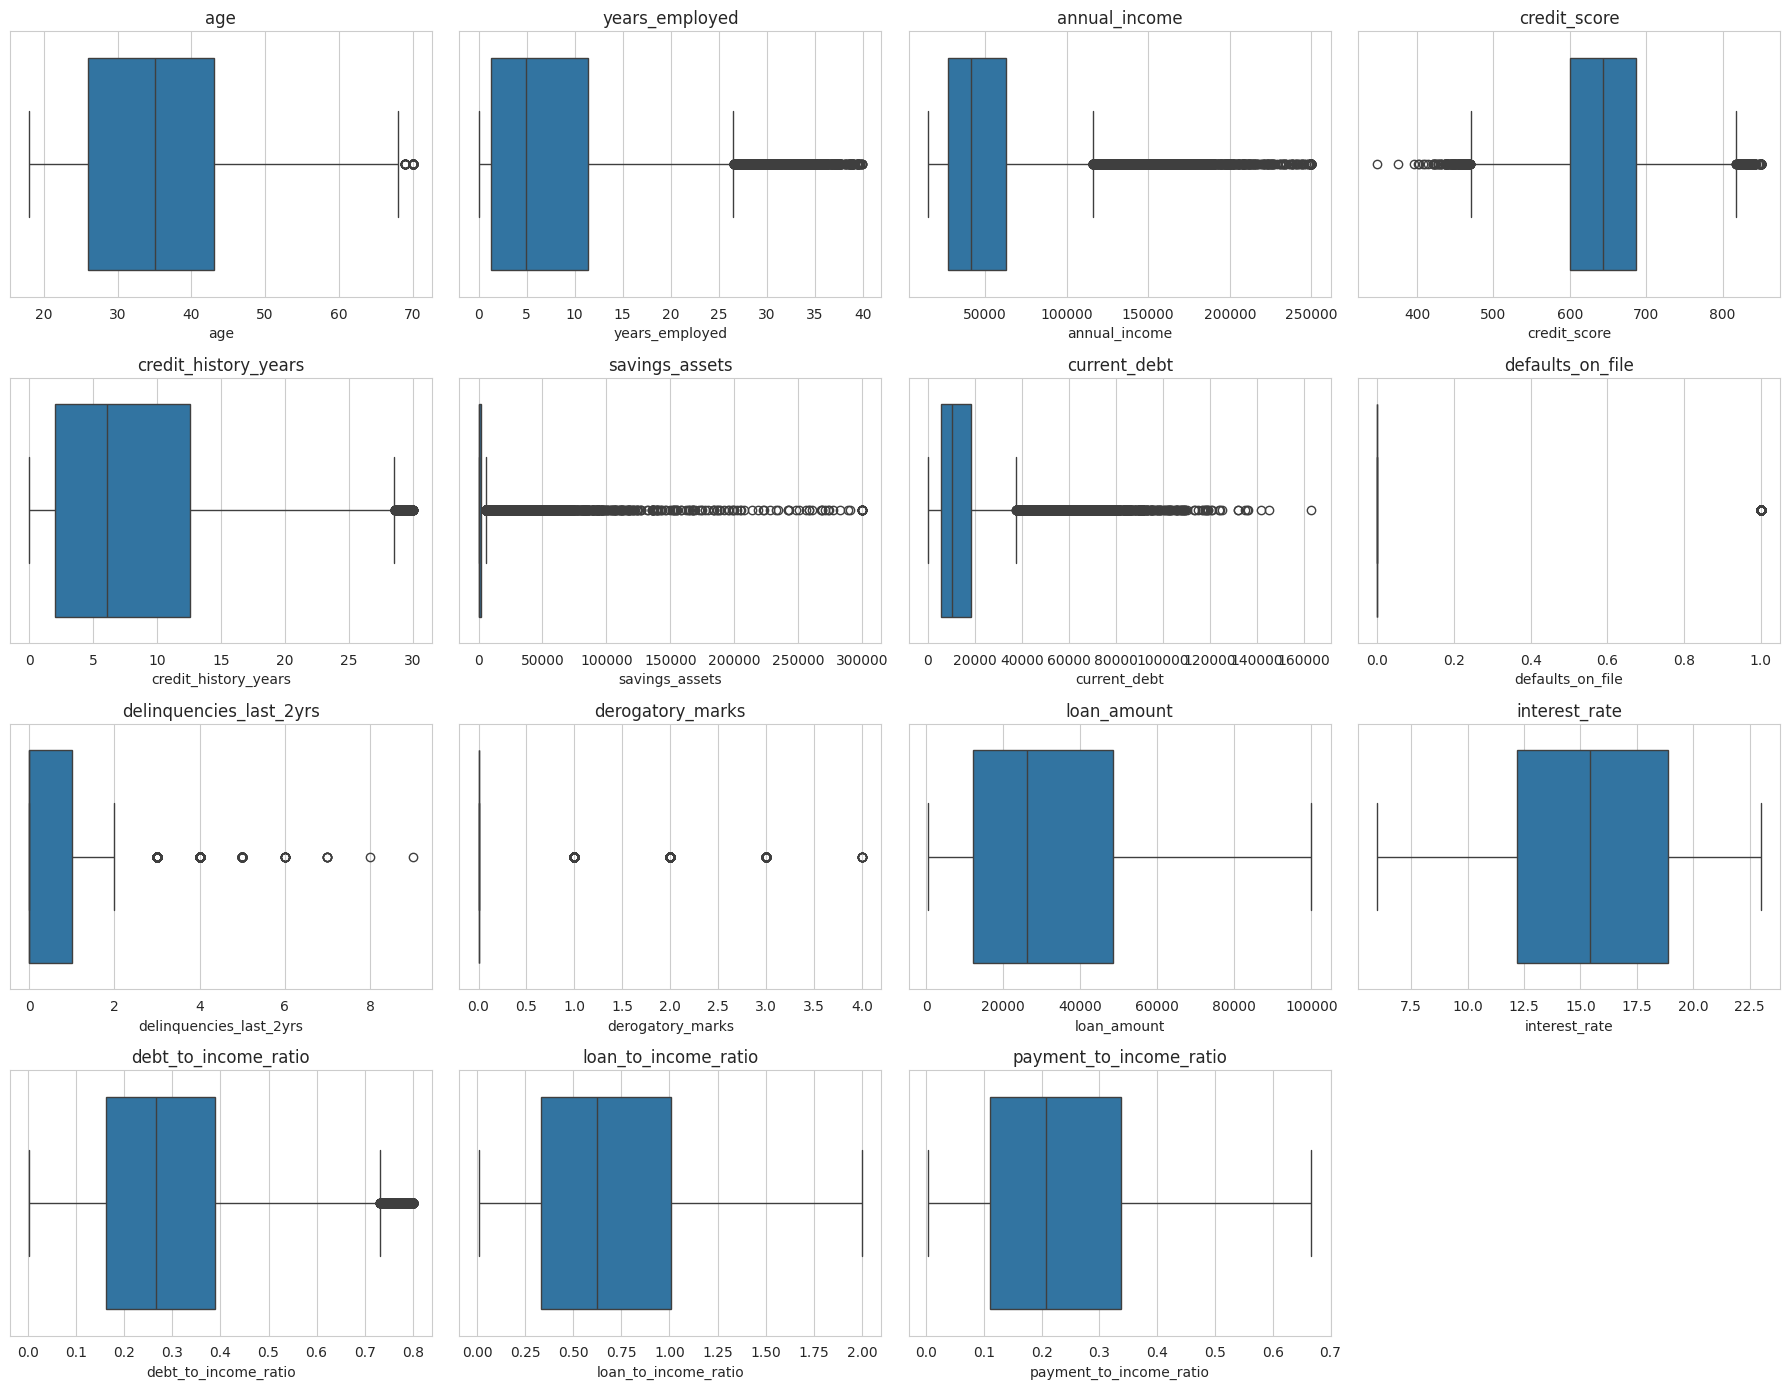

In [ ]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="#1f77b4" )
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Durante la evaluación de los valores atípicos (outliers), se determinó que las observaciones extremas son estructuralmente lógicas y consistentes con la naturaleza del dominio crediticio. Por consiguiente, no es necesario aplicar técnicas de eliminación o recorte de datos, ya que las magnitudes en el contexto de este dataset son naturales en el sector financiero. La existencia de clientes con ingresos o niveles de ahorro superiores representa una varianza económica real y no errores de captura o anomalías que deben ser depuradas para el modelo.

### 2.2 Variables categóricas

In [ ]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(f"Número de categorías: {df[col].nunique()}\n")

--- occupation_status ---
occupation_status
Employed         34971
Self-Employed    10179
Student           4850
Name: count, dtype: int64
Número de categorías: 3

--- product_type ---
product_type
Credit Card       22455
Personal Loan     17523
Line of Credit    10022
Name: count, dtype: int64
Número de categorías: 3

--- loan_intent ---
loan_intent
Personal              12429
Education             10134
Medical                7598
Business               7469
Home Improvement       7453
Debt Consolidation     4917
Name: count, dtype: int64
Número de categorías: 6



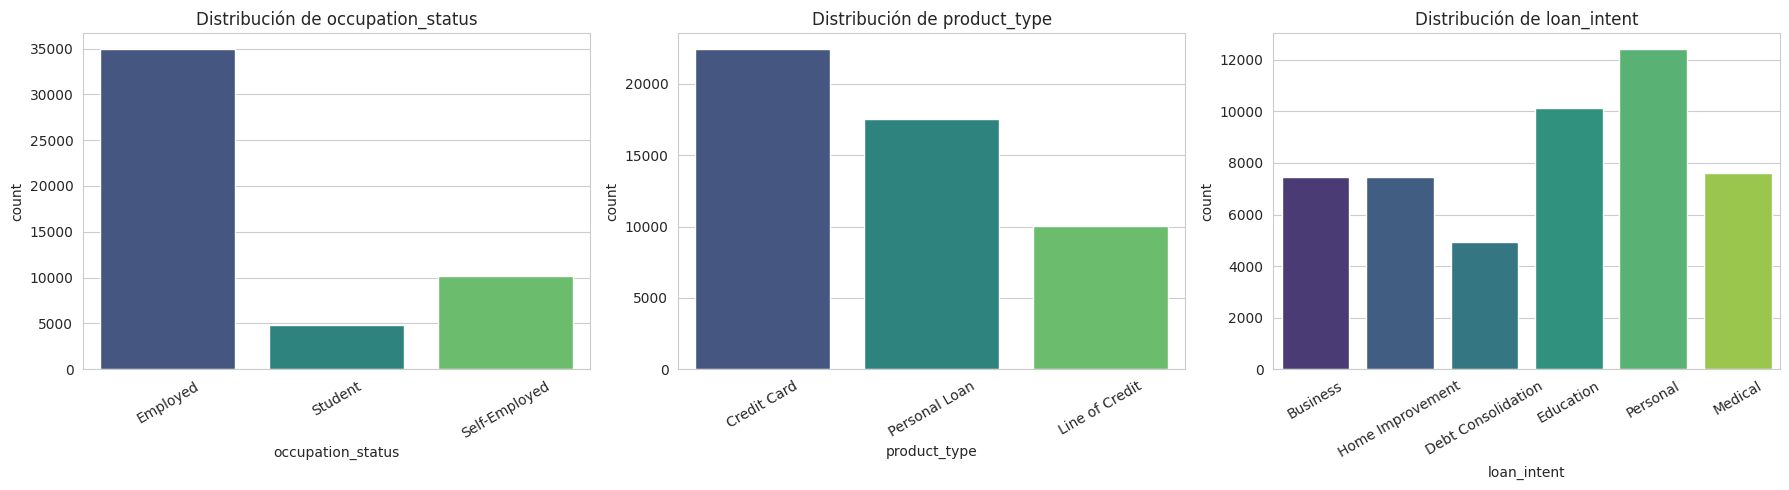

In [ ]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6 * len(categorical_cols), 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue=col, palette="viridis", legend=False)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 2.3 Variable objetivo (`loan_status`)

`loan_status` es una variable **categórica binaria** (0 = rechazado, 1 = aprobado). Es importante revisar si las clases están balanceadas

loan_status
1    27523
0    22477
Name: count, dtype: int64

Proporción de clases:
loan_status
1    0.55046
0    0.44954
Name: proportion, dtype: float64


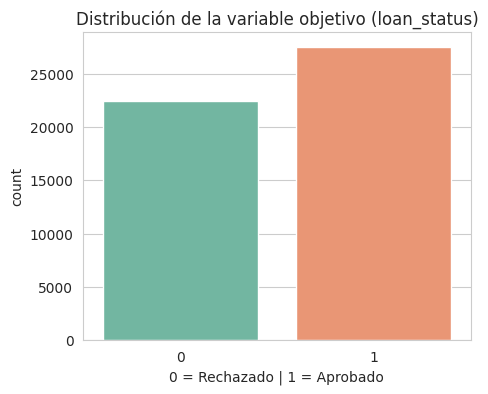

In [ ]:
print(df["loan_status"].value_counts())
print("\nProporción de clases:")
print(df["loan_status"].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="loan_status", hue="loan_status", palette="Set2", legend=False)
plt.title("Distribución de la variable objetivo (loan_status)")
plt.xlabel("0 = Rechazado | 1 = Aprobado")
plt.show()

### 2.4 Relación entre variables y la variable objetivo

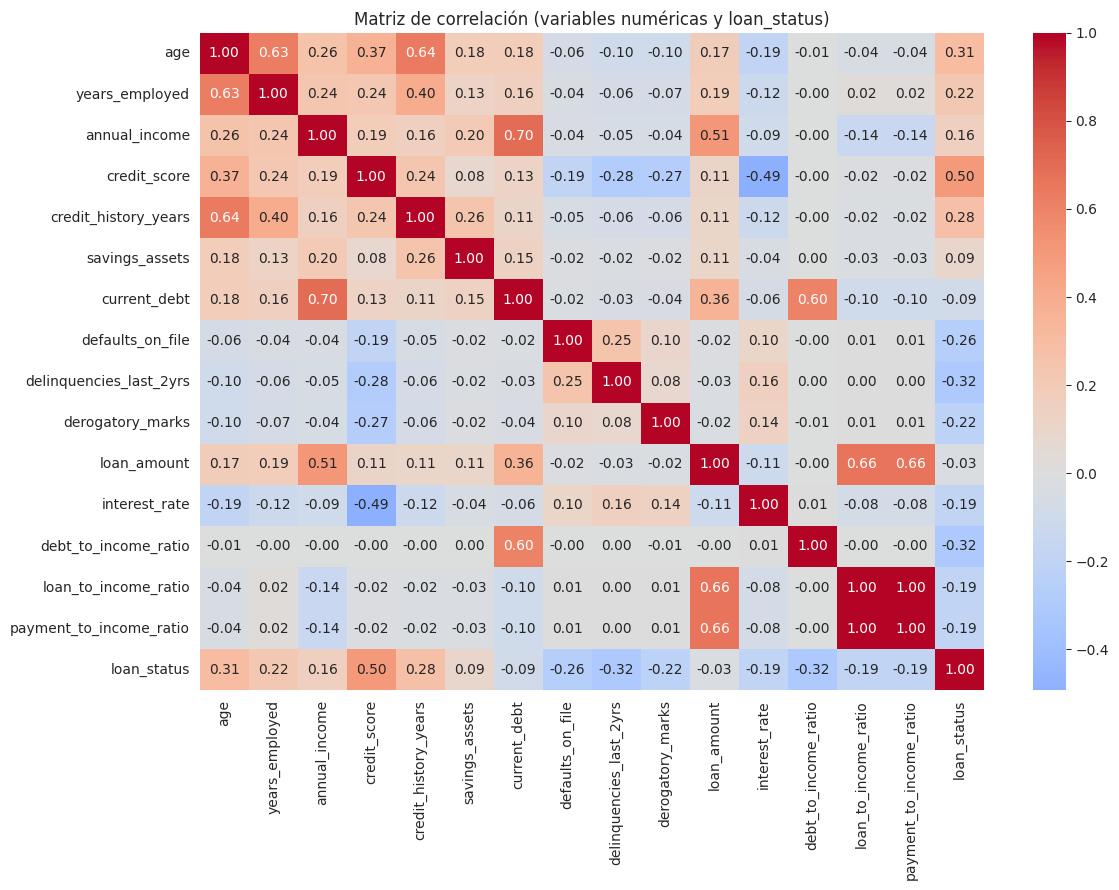

In [ ]:
corr = df[numeric_cols + ["loan_status"]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas y loan_status)")
plt.tight_layout()
plt.show()

### Análisis de Correlación y Multicolinealidad

* Se observa una fuerte correlación positiva entre `age` y `credit_history_years` (0.64), así como entre `age` y `years_employed` (0.63). Esta relación es estructuralmente lógica, ya que los solicitantes de mayor edad acumulan naturalmente un mayor historial crediticio y trayectoria laboral.


* La variable `annual_income` presenta una correlación fuertemente positiva (0.70) con la séptima variable del mapa de calor. Asumiendo la estructura del dataset, esto representa el volumen de deuda actual (`current_debt`) o el monto del préstamo. Esto refleja un principio estándar de originación de crédito: a mayores ingresos comprobables, el sistema financiero aprueba límites de exposición y endeudamiento nominalmente más altos.


* El `credit_score` exhibe correlaciones negativas significativas con varias columnas intermedias, destacando un -0.49 con  `Interests_rate`. Esto confirma estadísticamente que los perfiles con mayor puntaje tienen una relación inversa con los indicadores de riesgo y morosidad, validando la coherencia interna de los datos antes de entrenar los algoritmos.


* Se evidencian relaciones lineales importantes en los extremos de la matriz, donde `credit_score` alcanza un 0.50 y `age` un 0.31. Esto anticipa que tanto la calificación crediticia como la madurez demográfica del cliente actuarán como características determinantes en la capacidad del modelo para clasificar correctamente el estado final del crédito.


Correlación de cada variable numérica con loan_status (ordenada por magnitud):
credit_score               0.496316
delinquencies_last_2yrs   -0.318075
debt_to_income_ratio      -0.317363
age                        0.311524
credit_history_years       0.277103
defaults_on_file          -0.263033
derogatory_marks          -0.224735
years_employed             0.218875
payment_to_income_ratio   -0.193258
loan_to_income_ratio      -0.193252
interest_rate             -0.185179
annual_income              0.158466
savings_assets             0.094789
current_debt              -0.088494
loan_amount               -0.025987
Name: loan_status, dtype: float64


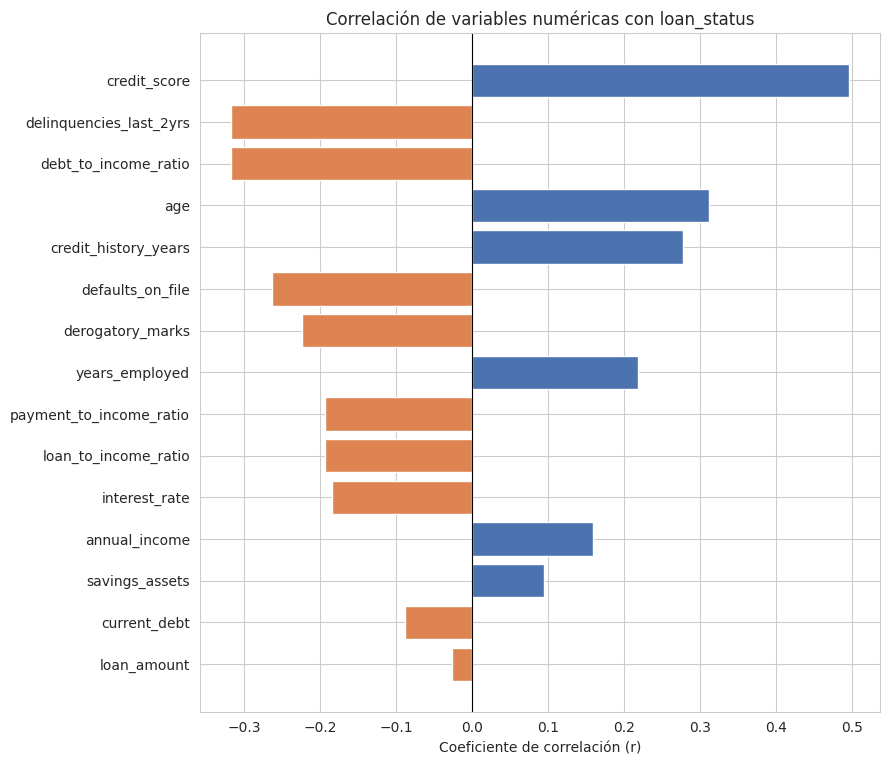

In [ ]:
# Correlación de las variables numéricas con la variable objetivo (todas, ordenadas por magnitud)
top_corr = corr["loan_status"].drop("loan_status").sort_values(key=lambda s: s.abs(), ascending=False)
print("Correlación de cada variable numérica con loan_status (ordenada por magnitud):")
print(top_corr)

colores = ["#4C72B0" if v > 0 else "#DD8452" for v in top_corr.values]
plt.figure(figsize=(9, 0.45 * len(top_corr) + 1))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colores[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación de variables numéricas con loan_status")
plt.xlabel("Coeficiente de correlación (r)")
plt.tight_layout()
plt.show()


En el siguiente gráfico se observa la relación de las variables númericas con la variable de salida y podemos observar que   `credit_score` es la variable que más influye en la aprobación del crédito o no, con una correlación de 0.5

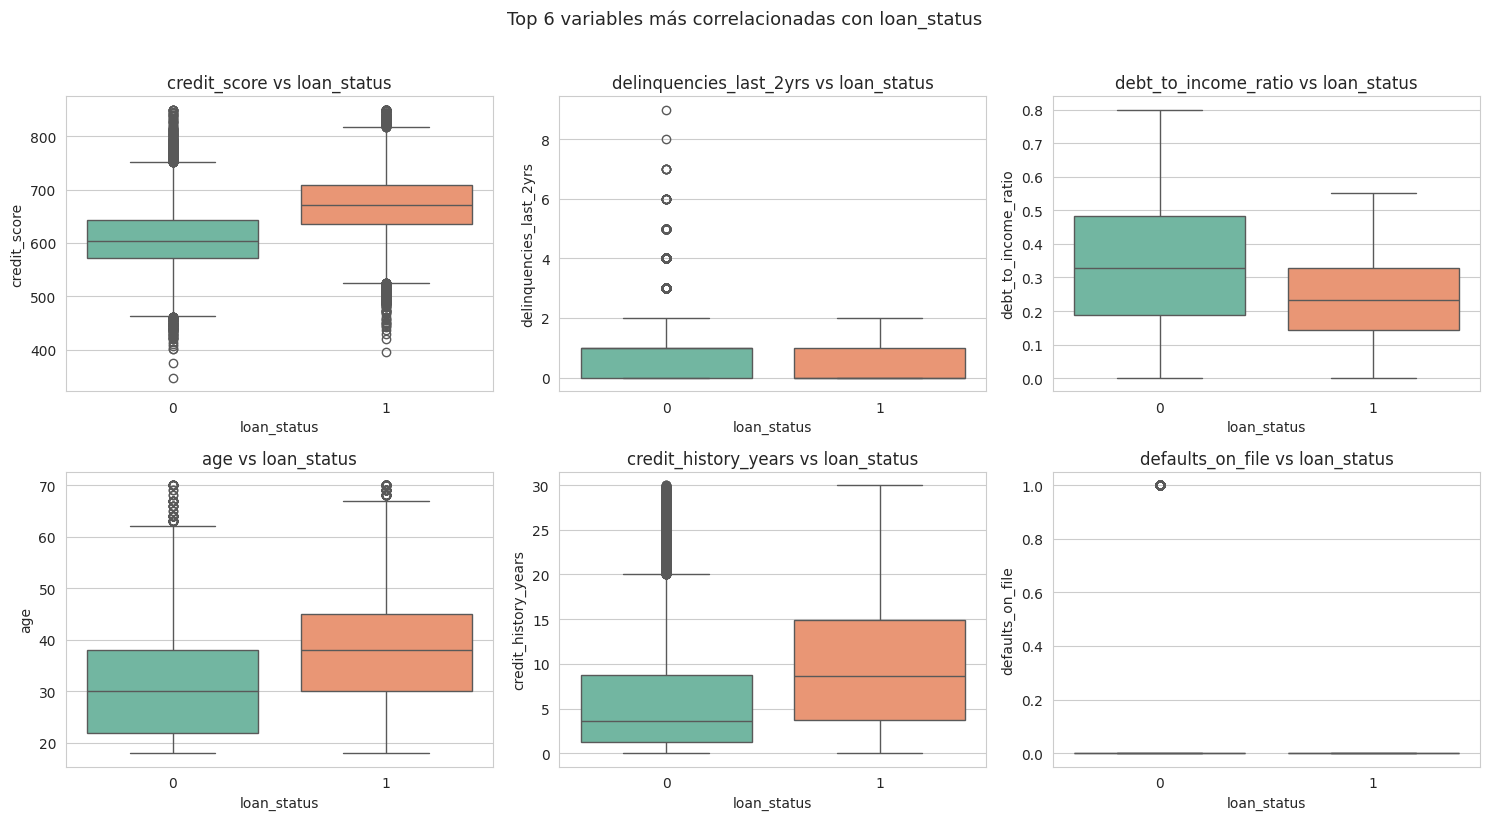

In [ ]:
# Boxplots solo de las variables MAS correlacionadas con loan_status (para que se vean bien)
N_TOP = 6
top_vars = top_corr.abs().sort_values(ascending=False).index[:N_TOP]

n_cols = 3
n_rows = -(-len(top_vars) // n_cols)  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, top_vars):
    sns.boxplot(data=df, x="loan_status", y=col, hue="loan_status", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} vs loan_status")

for j in range(len(top_vars), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Top {N_TOP} variables más correlacionadas con loan_status", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de datos

### Estrategia de Procesamiento y Transformación de Datos

* **Gestión de Escalas Numéricas:** El dataset presenta una disparidad de magnitudes evidente en el bloque numérico. Variables monetarias como `annual_income`, `savings_assets` y `current_debt` operan en miles o decenas de miles, mientras que los indicadores de mal comportamiento crediticio (como `defaults_on_file`, `delinquencies_last_2yrs` y `derogatory_marks`) son conteos unitarios de un solo dígito. Para evitar que las variables con valores absolutos más grandes dominen el aprendizaje del modelo, será indispensable aplicar un escalado ( `StandardScaler`) a estas características.


* **Codificación de Atributos Categóricos:** Identificamos tres columnas cualitativas que los algoritmos matemáticos no pueden procesar en formato de texto: `occupation_status`, `product_type` y `loan_intent`. Al tratarse de categorías nominales sin un orden jerárquico intrínseco, se aplicará la técnica de *One-Hot Encoding* (variables *dummy*). Esto transformará estas tres características en múltiples columnas binarias, permitiendo que el modelo aísle y pondere el riesgo específico de cada propósito de crédito o tipo de ocupación.


* **Preparación de la Variable Objetivo (`loan_status`):** Al ser un problema de evaluación de riesgo donde la salida es la clasificación del crédito, el paso final del procesamiento será la división del dataset (Train/Test Split). Es crítico configurar una partición estratificada para asegurar que la proporción original de morosidad se preserve intacta tanto en los datos de entrenamiento como en los de validación, garantizando así un aprendizaje y una evaluación sin sesgos.

Pasos:
1. Separar variables predictoras (`X`) y variable objetivo (`y`).
2. Dividir en conjunto de entrenamiento y prueba (80/20, estratificado por `loan_status`).
3. Codificar variables categóricas (`OneHotEncoder`) y escalar variables numéricas (`StandardScaler`) **dentro de un `Pipeline`**, para evitar fuga de información (*data leakage*) durante la validación cruzada.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

print("Columnas categóricas a codificar:", categorical_cols)
print("Columnas numéricas a escalar:", numeric_cols)

preprocessor

Columnas categóricas a codificar: ['occupation_status', 'product_type', 'loan_intent']
Columnas numéricas a escalar: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio']


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['occupation_status', 'product_type',
                                  'loan_intent']),
                                ('num', StandardScaler(),
                                 ['age', 'years_employed', 'annual_income',
                                  'credit_score', 'credit_history_years',
                                  'savings_assets', 'current_debt',
                                  'defaults_on_file', 'delinquencies_last_2yrs',
                                  'derogatory_marks', 'loan_amount',
                                  'interest_rate', 'debt_to_income_ratio',
                                  'loan_to_income_ratio',
                                  'payment_to_income_ratio'])])

## 4. Validación cruzada (10 folds) y entrenamiento de modelos

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, ParameterGrid
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import time

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultados = {}       # métricas resumidas por modelo
mejores_estimadores = {}  # mejor pipeline (ya entrenado) por modelo


def mostrar_malla(nombre, param_grid):
    # Muestra, para un modelo, cada hiperparametro con sus valores y la malla completa
    # (el producto cartesiano de todas las combinaciones) que GridSearchCV va a probar.
    print(f"Hiperparametros y valores a probar ({nombre}):")
    for k, v in param_grid.items():
        print(f"  - {k}: {v}")

    combinaciones = list(ParameterGrid(param_grid))
    malla_df = pd.DataFrame(combinaciones)
    malla_df.index = [f"combinacion_{i+1}" for i in range(len(malla_df))]

    print(f"\nMalla completa de combinaciones ({len(malla_df)} en total, "
          f"x 10 folds = {len(malla_df) * 10} ajustes de modelo):")
    display(malla_df)
    return malla_df


def evaluar_modelo(nombre, grid_search, X_test, y_test, tiempo_seg):
    # Evalua un GridSearchCV ya entrenado, imprime el reporte y guarda resultados.
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    metrics = {
        "CV ROC AUC (10-fold)": grid_search.best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC (test)": roc_auc_score(y_test, y_proba),
        "Tiempo entrenamiento (s)": tiempo_seg,
        "Mejores hiperparámetros": grid_search.best_params_,
    }
    resultados[nombre] = metrics
    mejores_estimadores[nombre] = best_model

    print(f"{nombre}")
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"CV ROC AUC (10-fold): {grid_search.best_score_:.4f}")
    print(f"Tiempo de entrenamiento: {tiempo_seg:.1f} s")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Rechazado", "Aprobado"]).plot(cmap="Blues")
    plt.title(f"Matriz de confusión — {nombre}")
    plt.show()

    return best_model

Esta celda no imprime nada por sí misma, pero construye la infraestructura común que se reutilizará en los cinco modelos siguientes, lo cual es clave para que la comparación final sea justa. `StratifiedKFold(n_splits=10, shuffle=True, random_state=42)` define una validación cruzada de 10 particiones (folds) que respeta la proporción de clases en cada una (igual que hizo `stratify` en el train/test split), y fija una semilla para que las particiones sean las mismas en todos los modelos. La función `mostrar_malla` sirve para dejar explícito, antes de entrenar, cuántas combinaciones de hiperparámetros va a probar `GridSearchCV` (el producto cartesiano de todos los valores posibles), lo que ayuda a entender por qué algunos modelos tardan mucho más que otros en entrenarse. La función `evaluar_modelo` centraliza el cálculo de accuracy, precision, recall, F1, ROC AUC en prueba y tiempo de entrenamiento, además de imprimir el reporte de clasificación y la matriz de confusión

### 4.1 Árboles de decisión (`DecisionTreeClassifier`)

Hiperparametros y valores a probar (Árbol de Decisión):
  - model__criterion: ['gini', 'entropy']
  - model__max_depth: [3, 5, 10, None]
  - model__min_samples_leaf: [1, 5, 10]

Malla completa de combinaciones (24 en total, x 10 folds = 240 ajustes de modelo):


,model__criterion,model__max_depth,model__min_samples_leaf
combinacion_1,gini,3.0,1
combinacion_2,gini,3.0,5
combinacion_3,gini,3.0,10
combinacion_4,gini,5.0,1
combinacion_5,gini,5.0,5
combinacion_6,gini,5.0,10
combinacion_7,gini,10.0,1
combinacion_8,gini,10.0,5
combinacion_9,gini,10.0,10
combinacion_10,gini,NaN,1


Árbol de Decisión
Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 10}
CV ROC AUC (10-fold): 0.9525
Tiempo de entrenamiento: 104.6 s
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      4495
           1       0.89      0.91      0.90      5505

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



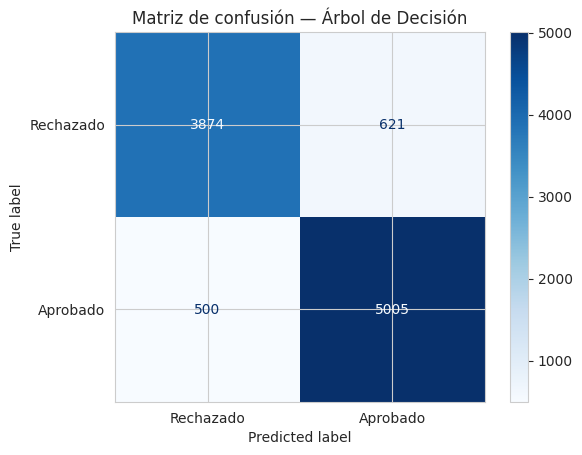

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
])

param_grid_dt = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_leaf": [1, 5, 10],
}

mostrar_malla("Árbol de Decisión", param_grid_dt)

t0 = time.time()
grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_dt.fit(X_train, y_train)
t_dt = time.time() - t0

_ = evaluar_modelo("Árbol de Decisión", grid_dt, X_test, y_test, t_dt)


La mejor combinación resultó ser criterio `entropy` (que mide la impureza usando ganancia de información en lugar del índice Gini), profundidad máxima 10 y mínimo 10 muestras por hoja, alcanzando un ROC AUC de 0.9525 en validación cruzada. Limitar la profundidad y exigir un mínimo de muestras por hoja son formas de controlar el sobreajuste típico de los árboles de decisión, que sin estas restricciones tienden a crecer hasta memorizar el conjunto de entrenamiento. En el conjunto de prueba, el modelo acierta el 89% de las veces, con un desempeño razonablemente parejo entre las dos clases (precision y recall entre 0.86 y 0.91). La matriz de confusión muestra 3.874 rechazados correctamente identificados frente a 621 falsos positivos (solicitudes que en realidad debían rechazarse pero el modelo aprobó), y 5.005 aprobados correctos frente a 500 falsos negativos (buenos solicitantes que el modelo rechazó por error)

In [ ]:
pipe_dt  # diagrama del Pipeline: prep (ColumnTransformer) + model (DecisionTree)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

### 4.2 Comité de máquinas (Bagging) con Regresión y Árboles



Hiperparametros y valores a probar (Bagging - Regresión Logística):
  - model__n_estimators: [50, 100]
  - model__max_samples: [0.7, 1.0]
  - model__estimator__C: [0.1, 1.0, 10.0]

Malla completa de combinaciones (12 en total, x 10 folds = 120 ajustes de modelo):


,model__estimator__C,model__max_samples,model__n_estimators
combinacion_1,0.1,0.7,50
combinacion_2,0.1,0.7,100
combinacion_3,0.1,1.0,50
combinacion_4,0.1,1.0,100
combinacion_5,1.0,0.7,50
combinacion_6,1.0,0.7,100
combinacion_7,1.0,1.0,50
combinacion_8,1.0,1.0,100
combinacion_9,10.0,0.7,50
combinacion_10,10.0,0.7,100


Bagging (Regresión Logística)
Mejores hiperparámetros: {'model__estimator__C': 10.0, 'model__max_samples': 1.0, 'model__n_estimators': 50}
CV ROC AUC (10-fold): 0.9460
Tiempo de entrenamiento: 1025.4 s
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4495
           1       0.87      0.89      0.88      5505

    accuracy                           0.87     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000



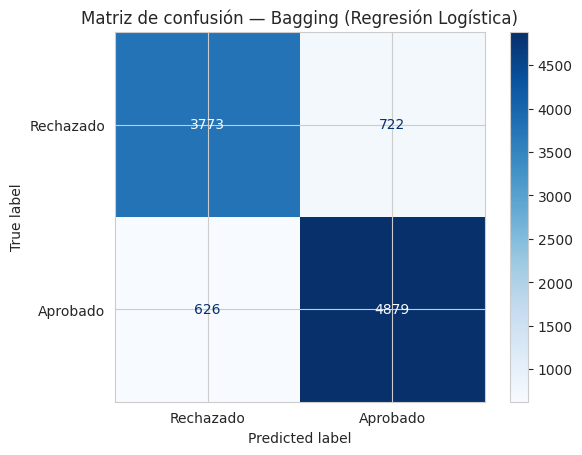

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

# --- 4.2.a Bagging con Regresión Logística como estimador base ---
pipe_bag_lr = Pipeline([
    ("prep", preprocessor),
    ("model", BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        random_state=42,
    )),
])

param_grid_bag_lr = {
    "model__n_estimators": [50, 100],
    "model__max_samples": [0.7, 1.0],
    "model__estimator__C": [0.1, 1.0, 10.0],
}

mostrar_malla("Bagging - Regresión Logística", param_grid_bag_lr)

t0 = time.time()
grid_bag_lr = GridSearchCV(pipe_bag_lr, param_grid_bag_lr, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_bag_lr.fit(X_train, y_train)
t_bag_lr = time.time() - t0

_ = evaluar_modelo("Bagging (Regresión Logística)", grid_bag_lr, X_test, y_test, t_bag_lr)

El Bagging consiste en entrenar muchos modelos base sobre distintas muestras aleatorias (con reemplazo) de los datos de entrenamiento, y luego promediar sus predicciones. Aquí se probó como estimador base una regresión logística, variando su regularización (`C`: 0.1, 1.0, 10.0), el porcentaje de datos usado por cada estimador (`max_samples`: 0.7 o 1.0) y el número de estimadores (50 o 100), en 12 combinaciones evaluadas en 10 folds (120 ajustes). El mejor resultado (C=10, `max_samples`=1.0, 50 estimadores) da un ROC AUC de 0.9460 en validación cruzada, que es incluso más bajo que el del árbol de decisión individual (0.9525). Esto no es un error, sino una consecuencia esperada de cómo funciona el Bagging: esta técnica reduce principalmente la *varianza* de un modelo, y es más útil cuando el modelo base ya tiene varianza alta

In [ ]:
pipe_bag_lr  # diagrama del Pipeline: prep + Bagging(LogisticRegression)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio'])])),
                ('model',
                 BaggingClassifier(estimator=LogisticRegression(max_iter=2000,
                                                                random_state=42),
                                   random_state=42))])

Hiperparametros y valores a probar (Bagging - Árboles de Decisión):
  - model__n_estimators: [50, 100]
  - model__max_samples: [0.7, 1.0]
  - model__estimator__max_depth: [3, 5, None]

Malla completa de combinaciones (12 en total, x 10 folds = 120 ajustes de modelo):


,model__estimator__max_depth,model__max_samples,model__n_estimators
combinacion_1,3.0,0.7,50
combinacion_2,3.0,0.7,100
combinacion_3,3.0,1.0,50
combinacion_4,3.0,1.0,100
combinacion_5,5.0,0.7,50
combinacion_6,5.0,0.7,100
combinacion_7,5.0,1.0,50
combinacion_8,5.0,1.0,100
combinacion_9,NaN,0.7,50
combinacion_10,NaN,0.7,100


Bagging (Árboles de Decisión)
Mejores hiperparámetros: {'model__estimator__max_depth': None, 'model__max_samples': 0.7, 'model__n_estimators': 100}
CV ROC AUC (10-fold): 0.9729
Tiempo de entrenamiento: 1697.7 s
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4495
           1       0.91      0.93      0.92      5505

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



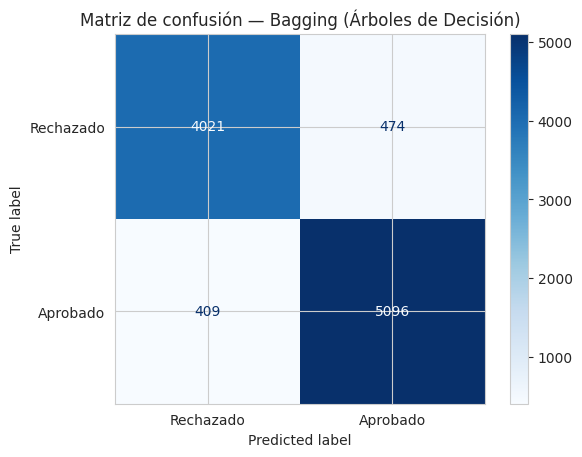

In [ ]:
# --- 4.2.b Bagging con Árboles de Decisión como estimador base ---
pipe_bag_tree = Pipeline([
    ("prep", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42,
    )),
])

param_grid_bag_tree = {
    "model__n_estimators": [50, 100],
    "model__max_samples": [0.7, 1.0],
    "model__estimator__max_depth": [3, 5, None],
}

mostrar_malla("Bagging - Árboles de Decisión", param_grid_bag_tree)

t0 = time.time()
grid_bag_tree = GridSearchCV(pipe_bag_tree, param_grid_bag_tree, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_bag_tree.fit(X_train, y_train)
t_bag_tree = time.time() - t0

_ = evaluar_modelo("Bagging (Árboles de Decisión)", grid_bag_tree, X_test, y_test, t_bag_tree)

Aquí se repite el mismo experimento de Bagging, pero usando árboles de decisión como estimador base en lugar de regresión logística, variando su profundidad máxima (3, 5 o sin límite), el porcentaje de muestreo (0.7 o 1.0) y el número de estimadores (50 o 100). El resultado mejora de forma notable: ROC AUC de 0.9729 en validación cruzada (frente a 0.9460 con regresión logística) y 91% de accuracy en prueba, con la mejor combinación usando árboles sin límite de profundidad, max_samples=0.7 y 100 estimadores. Esto ilustra exactamente el escenario donde el Bagging brilla: los árboles sin restricción de profundidad son modelos de alta varianza (cada uno, entrenado sobre una muestra distinta, puede verse bastante diferente y sobreajustarse a esa muestra particular), y al promediar las predicciones de 100 de ellos, los errores individuales de sobreajuste tienden a cancelarse entre sí, dejando una predicción conjunta más estable y precisa que la de un solo árbol

In [ ]:
pipe_bag_tree  # diagrama del Pipeline: prep + Bagging(DecisionTree)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio'])])),
                ('model',
                 BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                   random_state=42))])

In [ ]:
# Nos quedamos con la mejor variante de Bagging para la comparación final
mejor_bagging = max(
    ["Bagging (Regresión Logística)", "Bagging (Árboles de Decisión)"],
    key=lambda nombre: resultados[nombre]["ROC AUC (test)"],
)
print(f"Mejor variante de Bagging: {mejor_bagging}")

# La renombramos como 'Bagging (mejor variante)' para la tabla comparativa
resultados["Bagging (mejor variante)"] = resultados[mejor_bagging]
mejores_estimadores["Bagging (mejor variante)"] = mejores_estimadores[mejor_bagging]

Mejor variante de Bagging: Bagging (Árboles de Decisión)


### 4.3 Random Forest (`RandomForestClassifier`)

Hiperparametros y valores a probar (Random Forest):
  - model__n_estimators: [100, 200]
  - model__max_depth: [10, 20, None]
  - model__max_features: ['sqrt', 'log2']

Malla completa de combinaciones (12 en total, x 10 folds = 120 ajustes de modelo):


,model__max_depth,model__max_features,model__n_estimators
combinacion_1,10.0,sqrt,100
combinacion_2,10.0,sqrt,200
combinacion_3,10.0,log2,100
combinacion_4,10.0,log2,200
combinacion_5,20.0,sqrt,100
combinacion_6,20.0,sqrt,200
combinacion_7,20.0,log2,100
combinacion_8,20.0,log2,200
combinacion_9,NaN,sqrt,100
combinacion_10,NaN,sqrt,200


Random Forest
Mejores hiperparámetros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
CV ROC AUC (10-fold): 0.9756
Tiempo de entrenamiento: 1292.9 s
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4495
           1       0.92      0.93      0.92      5505

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



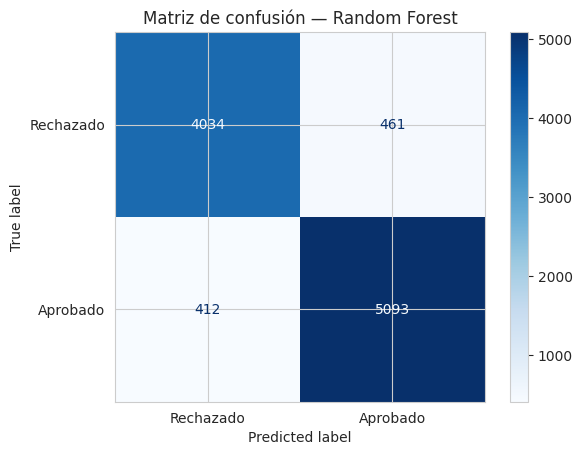

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__max_features": ["sqrt", "log2"],
}

mostrar_malla("Random Forest", param_grid_rf)

t0 = time.time()
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)
t_rf = time.time() - t0

best_rf = evaluar_modelo("Random Forest", grid_rf, X_test, y_test, t_rf)

Random Forest es, en esencia, una variante de Bagging con un ingrediente adicional: además de entrenar cada árbol sobre una muestra aleatoria de los datos, en cada división (*split*) de cada árbol solo se considera un subconjunto aleatorio de variables (controlado por `max_features`, aquí 'sqrt' o 'log2' del total de columnas). Esta aleatoriedad extra hace que los árboles del bosque sean menos parecidos entre sí (menos correlacionados). Los resultados confirman: con 200 árboles, sin límite de profundidad y `max_features='sqrt'`, se obtiene un ROC AUC de 0.9756 en validación cruzada, superando ligeramente al mejor Bagging (0.9729), con 91% de accuracy en prueba y un desempeño balanceado entre clases (precision 0.91-0.92, recall 0.90-0.93).

In [ ]:
pipe_rf  # diagrama del Pipeline: prep + RandomForest

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio'])])),
                ('model', RandomForestClassifier(random_state=42))])

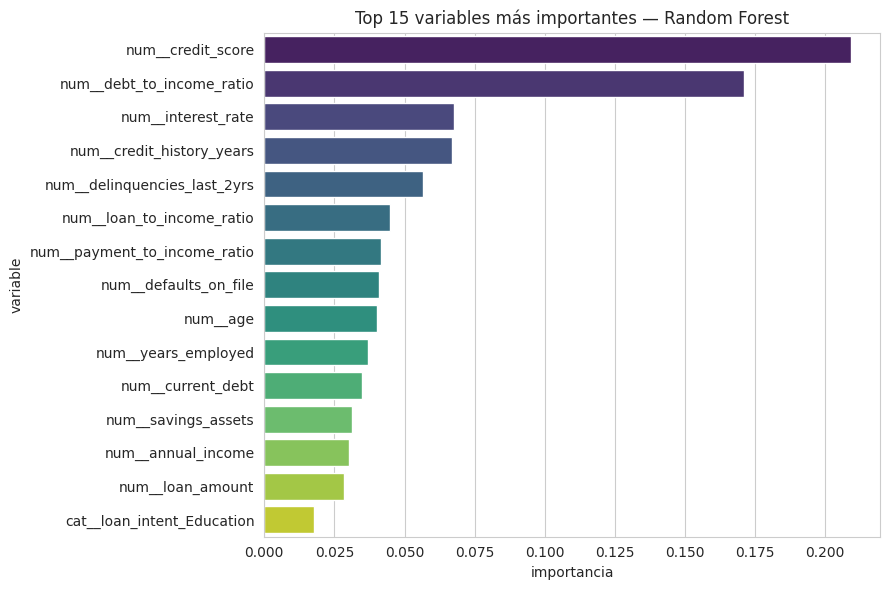

In [ ]:
# Importancia de variables (usando el mejor Random Forest)
importancias = best_rf.named_steps["model"].feature_importances_
nombres_features = best_rf.named_steps["prep"].get_feature_names_out()

imp_df = pd.DataFrame({"variable": nombres_features, "importancia": importancias})
imp_df = imp_df.sort_values("importancia", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x="importancia", y="variable", hue="variable", palette="viridis", legend=False)
plt.title("Top 15 variables más importantes — Random Forest")
plt.tight_layout()
plt.show()

 `feature_importances_` en Random Forest mide, para cada variable, cuánto contribuye en promedio a reducir la impureza cada vez que se usa para dividir un nodo, sumado sobre los 200 árboles del bosque; es una medida relativa, no una probabilidad, y todas las importancias suman 1 entre todas las variables (incluyendo las columnas generadas por el One-Hot Encoding). El gráfico confirma con datos del propio modelo lo que ya sugería la matriz de correlación: `credit_score` (≈0.21) y `debt_to_income_ratio` (≈0.17) dominan claramente por encima de las demás, seguidas por un grupo de importancia media formado por `interest_rate`, `credit_history_years` y `delinquencies_last_2yrs` (todas entre 0.05 y 0.07).

### 4.4 AdaBoost (`AdaBoostClassifier`)

Hiperparametros y valores a probar (AdaBoost):
  - model__n_estimators: [50, 100, 200]
  - model__learning_rate: [0.01, 0.1, 1.0]
  - model__estimator__max_depth: [1, 2, 3]

Malla completa de combinaciones (27 en total, x 10 folds = 270 ajustes de modelo):


,model__estimator__max_depth,model__learning_rate,model__n_estimators
combinacion_1,1,0.01,50
combinacion_2,1,0.01,100
combinacion_3,1,0.01,200
combinacion_4,1,0.10,50
combinacion_5,1,0.10,100
combinacion_6,1,0.10,200
combinacion_7,1,1.00,50
combinacion_8,1,1.00,100
combinacion_9,1,1.00,200
combinacion_10,2,0.01,50


AdaBoost
Mejores hiperparámetros: {'model__estimator__max_depth': 3, 'model__learning_rate': 1.0, 'model__n_estimators': 200}
CV ROC AUC (10-fold): 0.9837
Tiempo de entrenamiento: 2943.1 s
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      4495
           1       0.93      0.94      0.94      5505

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



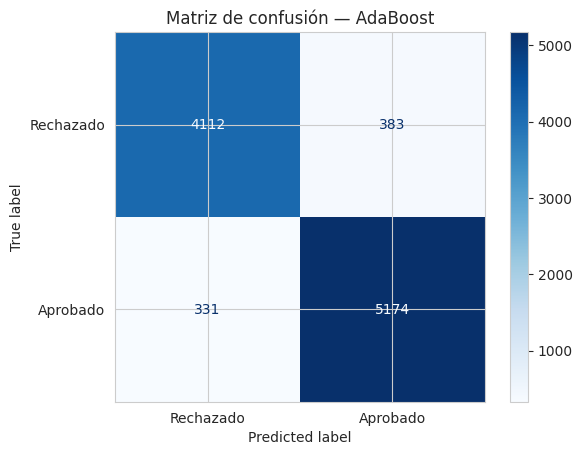

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

pipe_ada = Pipeline([
    ("prep", preprocessor),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42,
    )),
])


param_grid_ada = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1.0],
    "model__estimator__max_depth": [1, 2, 3],
}

mostrar_malla("AdaBoost", param_grid_ada)

t0 = time.time()
grid_ada = GridSearchCV(pipe_ada, param_grid_ada, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_ada.fit(X_train, y_train)
t_ada = time.time() - t0

_ = evaluar_modelo("AdaBoost", grid_ada, X_test, y_test, t_ada)

AdaBoost tiene un enfoque distinto y complementario al Bagging: en lugar de entrenar todos los modelos en paralelo sobre muestras aleatorias independientes, entrena los árboles de forma secuencial, y en cada paso le da más peso a los ejemplos que el árbol anterior clasificó mal, forzando a los siguientes árboles a concentrarse en los casos más difíciles. Se probaron 27 combinaciones (3 profundidades del árbol base × 3 tasas de aprendizaje × 3 números de estimadores), evaluadas en 10 folds (270 ajustes en total). La mejor combinación —árboles de profundidad 3, `learning_rate`=1.0 y 200 estimadores— logra un ROC AUC de 0.9837 en validación cruzada y 93% de accuracy en prueba, superando a Random Forest (0.9756)

In [ ]:
pipe_ada  # diagrama del Pipeline: prep + AdaBoost

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks',
                                                   'loan_amount',
                                                   'interest_rate',
                                                   'debt_to_income_ratio',
                                                   'loan_to_income_ratio',
                                                   'payment_to_income_ratio'])])),
                ('model',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                    random_state=42))])

## 4.5 XGBoost (`XGBClassifier`)

Hiperparametros y valores a probar (XGBoost):
  - model__n_estimators: [100, 200]
  - model__max_depth: [3, 5]
  - model__learning_rate: [0.05, 0.1]
  - model__subsample: [0.8, 1.0]

Malla completa de combinaciones (16 en total, x 10 folds = 160 ajustes de modelo):


,model__learning_rate,model__max_depth,model__n_estimators,model__subsample
combinacion_1,0.05,3,100,0.8
combinacion_2,0.05,3,100,1.0
combinacion_3,0.05,3,200,0.8
combinacion_4,0.05,3,200,1.0
combinacion_5,0.05,5,100,0.8
combinacion_6,0.05,5,100,1.0
combinacion_7,0.05,5,200,0.8
combinacion_8,0.05,5,200,1.0
combinacion_9,0.10,3,100,0.8
combinacion_10,0.10,3,100,1.0


XGBoost
Mejores hiperparámetros: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
CV ROC AUC (10-fold): 0.9848
Tiempo de entrenamiento: 138.0 s
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      4495
           1       0.93      0.94      0.93      5505

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



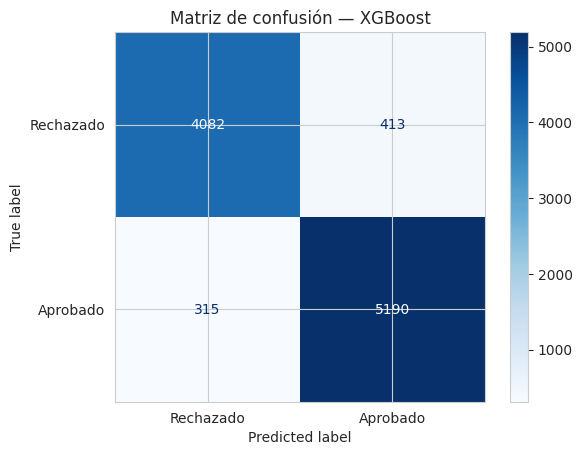

In [ ]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        random_state=42, eval_metric="logloss", n_jobs=1
    )),
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
}

mostrar_malla("XGBoost", param_grid_xgb)

t0 = time.time()
grid_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_xgb.fit(X_train, y_train)
t_xgb = time.time() - t0

best_xgb = evaluar_modelo("XGBoost", grid_xgb, X_test, y_test, t_xgb)

XGBoost es también un algoritmo de boosting, pero más sofisticado y optimizado que AdaBoost: en cada paso, en lugar de solo reponderar ejemplos mal clasificados, ajusta un nuevo árbol para corregir directamente el error (el gradiente de la función de pérdida) que dejó el conjunto de árboles anterior, e incluye regularización para controlar el sobreajuste. Se probaron 16 combinaciones (número de árboles, profundidad, tasa de aprendizaje y porcentaje de submuestreo por árbol), evaluadas en 10 folds (160 ajustes). La mejor combinación (`learning_rate`=0.1, `max_depth`=5, 200 estimadores, `subsample`=0.8) logra el mejor resultado de todo el notebook: ROC AUC de 0.9848 en validación cruzada y 93% de accuracy en prueba

In [ ]:
pipe_xgb  # diagrama del Pipeline: prep + XGBoost

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation_status',
                                                   'product_type',
                                                   'loan_intent']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'credit_history_years',
                                                   'savings_assets',
                                                   'current_debt',
                                                   'defaults_on_file',
                                                   'delinquencies_last_2yrs',
                                                   'derogatory_marks...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=1,
                               num_parallel_tree=None, ...))])

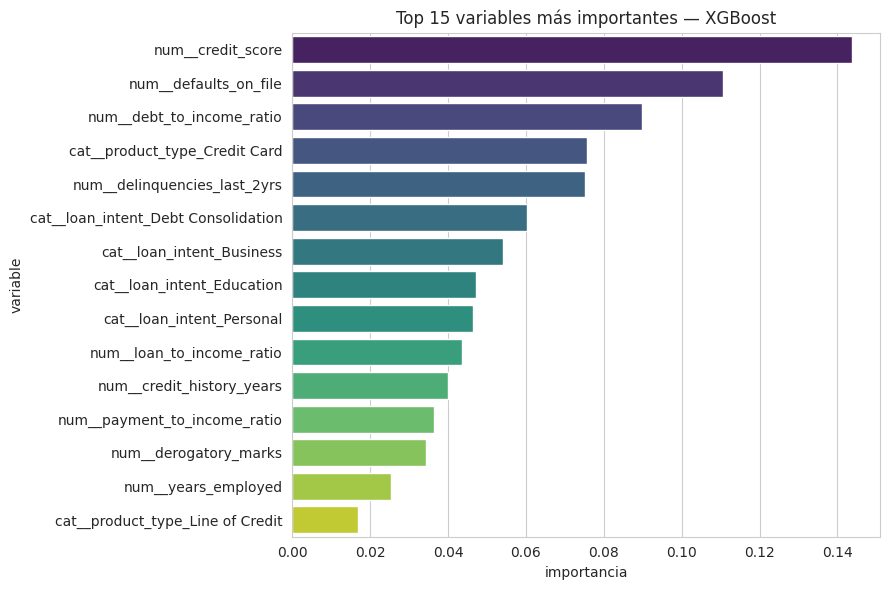

In [ ]:
# Importancia de variables (usando el mejor XGBoost)
importancias_xgb = best_xgb.named_steps["model"].feature_importances_
nombres_features_xgb = best_xgb.named_steps["prep"].get_feature_names_out()

imp_xgb_df = pd.DataFrame({"variable": nombres_features_xgb, "importancia": importancias_xgb})
imp_xgb_df = imp_xgb_df.sort_values("importancia", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_xgb_df, x="importancia", y="variable", hue="variable", palette="viridis", legend=False)
plt.title("Top 15 variables más importantes — XGBoost")
plt.tight_layout()
plt.show()

## 5. Comparación de modelos

Una vez entrenados los cinco modelos bajo el mismo protocolo (idéntico pipeline de
preprocesamiento y validación cruzada de 10 folds), consolidamos todos los resultados en
una sola tabla para compararlos de forma justa: las mismas métricas, medidas sobre el
mismo conjunto de prueba.

El criterio principal de comparación es el **ROC AUC**, porque mide la capacidad de
discriminación del modelo con independencia del umbral de decisión y es robusto frente al
ligero desbalance de clases (55% aprobados / 45% rechazados). Lo complementamos con
accuracy, precision, recall y F1-score para entender el comportamiento en el punto de
operación por defecto, y con el **tiempo de entrenamiento**, que en un escenario real es
determinante para elegir un modelo mantenible y reentrenable en producción.

In [ ]:
tabla_comparativa = pd.DataFrame(resultados).T
tabla_comparativa = tabla_comparativa.drop(index=["Bagging (Regresión Logística)", "Bagging (Árboles de Decisión)"], errors="ignore")
tabla_comparativa = tabla_comparativa.rename(index={"Bagging (mejor variante)": "Bagging"})

cols_numericas = ["CV ROC AUC (10-fold)", "Accuracy", "Precision", "Recall", "F1-score", "ROC AUC (test)", "Tiempo entrenamiento (s)"]
tabla_comparativa_num = tabla_comparativa[cols_numericas].astype(float).sort_values("ROC AUC (test)", ascending=False)

tabla_comparativa_num.style.background_gradient(cmap="Greens", subset=["ROC AUC (test)", "F1-score", "Accuracy"])


,CV ROC AUC (10-fold),Accuracy,Precision,Recall,F1-score,ROC AUC (test),Tiempo entrenamiento (s)
XGBoost,0.984848,0.927200,0.926289,0.942779,0.934462,0.984260,137.965732
AdaBoost,0.983746,0.928600,0.931078,0.939873,0.935455,0.983496,2943.107866
Random Forest,0.975617,0.912700,0.916997,0.925159,0.921060,0.975296,1292.861538
Bagging,0.972932,0.911700,0.914901,0.925704,0.920271,0.973116,1697.673208
Árbol de Decisión,0.952454,0.887900,0.889620,0.909173,0.899290,0.953151,104.596090


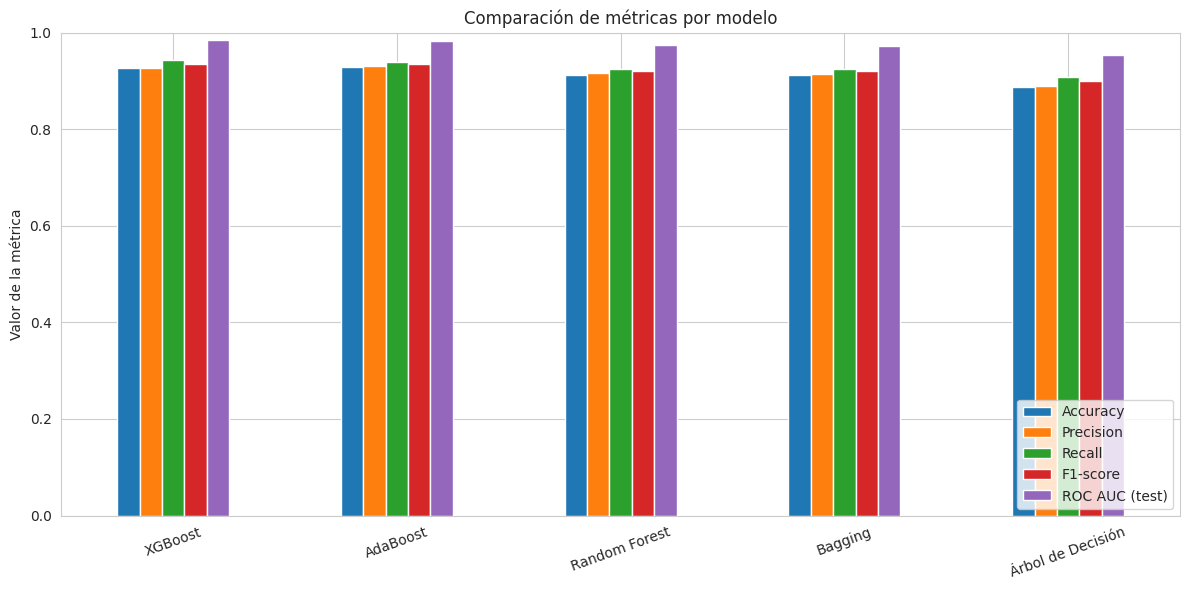

In [ ]:
# Gráfico comparativo de métricas por modelo
metricas_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC (test)"]
tabla_comparativa_num[metricas_plot].plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de métricas por modelo")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


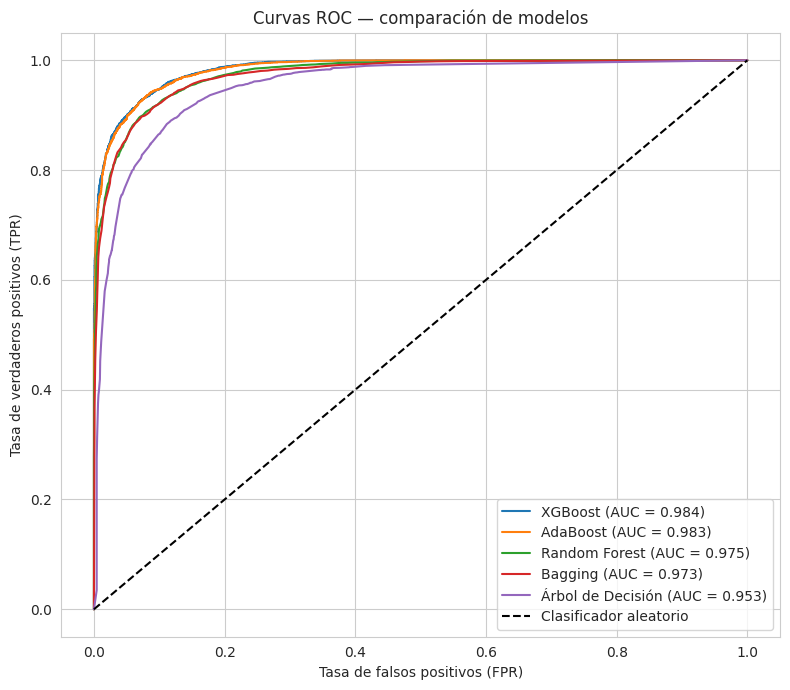

In [ ]:
# Curvas ROC comparativas
plt.figure(figsize=(8, 7))
for nombre in tabla_comparativa_num.index:
    modelo = mejores_estimadores[nombre] if nombre in mejores_estimadores else mejores_estimadores[
        "Bagging (mejor variante)" if nombre == "Bagging" else nombre
    ]
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
mejor_modelo_nombre = tabla_comparativa_num["ROC AUC (test)"].idxmax()
mejor_modelo_nombre_real = "Bagging (mejor variante)" if mejor_modelo_nombre == "Bagging" else mejor_modelo_nombre
mejor_modelo = mejores_estimadores[mejor_modelo_nombre_real]

print(f"Mejor modelo según ROC AUC en test: {mejor_modelo_nombre}")
print(tabla_comparativa_num.loc[mejor_modelo_nombre])

Mejor modelo según ROC AUC en test: XGBoost
CV ROC AUC (10-fold)          0.984848
Accuracy                      0.927200
Precision                     0.926289
Recall                        0.942779
F1-score                      0.934462
ROC AUC (test)                0.984260
Tiempo entrenamiento (s)    137.965732
Name: XGBoost, dtype: float64


### Interpretación de la comparación

**1. Existe una jerarquía clara entre familias de modelos.** Los resultados reproducen el
orden esperado en teoría: el árbol de decisión individual es el más débil (ROC AUC 0.953,
accuracy 89%), los métodos de *bagging* (Bagging con árboles y Random Forest) suben a la
franja de 0.973–0.975, y los métodos de *boosting* (AdaBoost y XGBoost) encabezan la tabla
con ~0.984. El salto del árbol simple a cualquier ensamble es sustancial (casi 4 puntos de
accuracy), lo que confirma que combinar muchos árboles reduce el error frente a uno solo.

**2. El boosting supera al bagging.** Los dos mejores modelos son de boosting. La razón es
conceptual: el bagging (Random Forest, Bagging) ataca principalmente la **varianza**,
promediando árboles entrenados en paralelo sobre muestras distintas; el boosting, en
cambio, ataca también el **sesgo**, entrenando árboles en secuencia donde cada uno corrige
los errores del anterior. En este problema esa corrección secuencial marca la diferencia:
~1 punto de ROC AUC y ~1.5 puntos de accuracy sobre Random Forest.

**3. XGBoost y AdaBoost empatan en calidad; el tiempo decide.** Si se miran solo las
métricas de acierto, ambos son prácticamente indistinguibles: AdaBoost aventaja por
milésimas en accuracy, precision y F1, mientras XGBoost aventaja por milésimas en ROC AUC
(CV y test) y en recall. Ninguna diferencia es relevante en la práctica. La verdadera
brecha está en el **costo computacional**: XGBoost entrena en 138 s frente a los 2.943 s
de AdaBoost, es decir, **unas 21 veces más rápido**, alcanzando la misma o mejor calidad.
Es notable además que XGBoost sea el segundo modelo más rápido de todo el notebook, solo
por detrás del árbol simple: ofrece el mejor desempeño con uno de los menores costos.

**4. No hay sobreajuste y la metodología es confiable.** Para todos los modelos, el
ROC AUC estimado por validación cruzada (10-fold) y el medido en el conjunto de prueba
—que el modelo nunca vio— son casi idénticos (por ejemplo, XGBoost: 0.9848 en CV vs.
0.9843 en test). Esta consistencia indica que los modelos generalizan bien y que la
estimación por validación cruzada fue una guía fiel del comportamiento real.

**5. Lectura de negocio.** En todos los modelos el *recall* supera a la *precision*, es
decir, capturan bien a los solicitantes aprobables (pocos falsos negativos). Para una
entidad financiera, sin embargo, conviene vigilar también la *precision* de la clase
"aprobado", porque un falso positivo (aprobar a alguien que debía rechazarse) suele ser más
costoso —riesgo de impago— que un falso negativo (rechazar a un buen cliente). XGBoost
mantiene ambas métricas por encima de 0.92, un equilibrio adecuado para este uso.

**Conclusión.** El **XGBoost** es el mejor modelo para este problema: obtiene el mayor
ROC AUC tanto en validación cruzada como en test, es competitivo o superior en el resto de
métricas y logra todo esto con el mejor balance desempeño/costo, siendo ~21 veces más
rápido que su competidor más cercano. Por eso es el modelo que se selecciona y se guarda
en la siguiente sección.

## 6. Guardado del mejor modelo con `joblib`

`joblib` es la librería recomendada por scikit-learn para serializar (guardar/cargar) modelos entrenados, ya que maneja de forma eficiente los arreglos de NumPy que suelen contener los objetos de `scikit-learn` (ver [documentación oficial de joblib](https://joblib.readthedocs.io/en/latest/persistence.html) y la [guía de model persistence de scikit-learn](https://scikit-learn.org/stable/model_persistence.html)).

In [ ]:
import joblib

nombre_archivo = "mejor_modelo_loan_approval.joblib"
joblib.dump(mejor_modelo, nombre_archivo)
print(f"Modelo '{mejor_modelo_nombre}' guardado en: {nombre_archivo}")

Modelo 'XGBoost' guardado en: mejor_modelo_loan_approval.joblib


In [ ]:
# Verificación: cargar el modelo guardado y probar que funciona correctamente
modelo_cargado = joblib.load(nombre_archivo)

pred_ejemplo = modelo_cargado.predict(X_test.iloc[:5])
proba_ejemplo = modelo_cargado.predict_proba(X_test.iloc[:5])[:, 1]

print("Predicciones de ejemplo (0 = Rechazado, 1 = Aprobado):", pred_ejemplo)
print("Probabilidades de aprobación:", np.round(proba_ejemplo, 3))
print("Valores reales:", y_test.iloc[:5].values)


Predicciones de ejemplo (0 = Rechazado, 1 = Aprobado): [0 0 1 0 0]
Probabilidades de aprobación: [0.005 0.013 0.996 0.    0.397]
Valores reales: [0 0 1 0 0]


La verificación confirma que el modelo se guardó y se recargó correctamente: sobre cinco
solicitudes de prueba, el modelo cargado desde disco reproduce exactamente las mismas
predicciones que el original (`[0 0 1 0 0]`), coincidiendo con los valores reales. Las
probabilidades asociadas son además coherentes: muy cercanas a 0 para los rechazos claros,
0.996 para la aprobación evidente y 0.397 para el último caso —una solicitud "de frontera"
que el modelo, con buen criterio, inclina hacia el rechazo.

Un punto importante es que con `joblib` no se serializa únicamente el clasificador XGBoost,
sino el **pipeline completo** (`ColumnTransformer` de preprocesamiento + modelo). Esto
significa que el archivo `.joblib` recibe los datos crudos del solicitante y se encarga
internamente de codificar las variables categóricas y escalar las numéricas antes de
predecir. En la práctica, el modelo queda listo para producción: basta con cargar el
archivo y llamar a `predict`, sin tener que reconstruir el preprocesamiento por separado.

## 7. Conclusiones

**Se resolvió el problema planteado.** El objetivo era determinar si, a partir del perfil
financiero de un solicitante, es posible predecir automáticamente la aprobación o el
rechazo de un préstamo. La respuesta es afirmativa: el modelo final (XGBoost) clasifica
correctamente cerca del **93% de las solicitudes** y alcanza un **ROC AUC de 0.984**, un
nivel de discriminación muy alto para una decisión crediticia. La entidad financiera podría
usarlo como apoyo para automatizar decisiones de bajo riesgo y priorizar la revisión
manual en los casos dudosos.

**El modelo elegido es interpretable y coherente con el negocio.** Más allá del acierto,
el análisis de importancia de variables (Random Forest y XGBoost) revela *en qué* se basa
la decisión: dominan el `credit_score` (≈0.21) y el `debt_to_income_ratio` (≈0.17), seguidos
de la tasa de interés, los años de historial crediticio y las moras recientes. Es
tranquilizador que los factores más influyentes sean precisamente los que un analista de
crédito consideraría razonables —capacidad de pago e historial—, lo que da confianza en que
el modelo aprendió relaciones con sentido y no artefactos espurios de los datos.

**Los hallazgos del EDA se confirmaron a lo largo del proyecto.** El análisis exploratorio
ya anticipaba un desbalance leve de clases (≈55% aprobados / 45% rechazados), grandes
diferencias de escala entre variables y una correlación fuerte de `credit_score` y los
ratios de endeudamiento con la variable objetivo. El desbalance se manejó usando validación
cruzada estratificada y priorizando el ROC AUC sobre la simple exactitud; las diferencias
de escala se resolvieron con el escalado dentro del pipeline; y las importancias del modelo
final coincidieron con las correlaciones observadas al inicio, cerrando el círculo del
análisis.

**Sobre la comparación de modelos.** Se entrenaron las cinco familias exigidas (árbol de
decisión, bagging, Random Forest, AdaBoost y XGBoost) con validación cruzada de 10 folds y
malla de hiperparámetros. Se confirmó la jerarquía esperada árbol simple < bagging
boosting, y XGBoost resultó el mejor por combinar la máxima calidad con el menor costo
(≈21 veces más rápido que AdaBoost, de calidad equivalente).

**Limitaciones.** Conviene ser prudente: (1) el dataset es sintético ("realistic" pero
generado, no de operaciones reales de un banco), por lo que las relaciones aprendidas
pueden ser más limpias que en la práctica; (2) las decisiones se evaluaron con el umbral
por defecto de 0.5, sin ajustarlo al costo real de cada tipo de error; (3) no se abordó
la posible presencia de sesgos (por ejemplo, si alguna variable actúa como proxy de
características protegidas), algo crítico en un contexto crediticio real; y (4) AdaBoost
resultó impráctico por su tiempo de entrenamiento (~49 min).
